In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score

In [3]:
df = pd.read_csv('online_shoppers_intention.csv')

In [4]:
X_raw = df.drop(columns=['Revenue'])
y = df['Revenue'].astype(int) #map true false to 1 and 0

In [5]:
X_encoded = pd.get_dummies(X_raw, columns=['Month', 'VisitorType'],drop_first=True)

In [6]:
TRAINING_FEATURE_SCHEMA = X_encoded.columns.tolist()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
# Model INTERFACE INITIALIZATION
clf_tree = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
clf_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [10]:
# EVALUATION METRICS DASHBOARD
y_pred = clf_tree.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(f"Classification Report: {classification_report(y_test, y_pred)}")

Accuracy: 0.8962

Classification Report:
Classification Report:               precision    recall  f1-score   support

           0       0.91      0.98      0.94      2084
           1       0.77      0.47      0.58       382

    accuracy                           0.90      2466
   macro avg       0.84      0.72      0.76      2466
weighted avg       0.89      0.90      0.89      2466



In [12]:
# LIVE INFERENCE ENGINE (REALISTIC MANUAL ENTRY)
print("=== LIVE INFERENCE ENGINE ===")

# Enter raw data stream manually, exactly as they arrive from a real website
unseen_raw_traffic = pd.DataFrame([
{
'Administrative': 0, 'Administrative_Duration': 0.0,
'Informational': 0, 'Informational_Duration': 0.0,
'ProductRelated': 3, 'ProductRelated_Duration': 12.5,
'BounceRates': 0.18, 'ExitRates': 0.20, 'PageValues': 0.0,
'SpecialDay': 0.0, 'Month': 'Nov', 'OperatingSystems': 2,
'Browser': 2, 'Region': 1, 'TrafficType': 3,
'VisitorType': 'Returning_Visitor', 'Weekend': False
},
{
'Administrative': 4, 'Administrative_Duration': 110.5,
'Informational': 2, 'Informational_Duration': 45.0,
'ProductRelated': 35, 'ProductRelated_Duration': 1420.2,
'BounceRates': 0.00, 'ExitRates': 0.01, 'PageValues': 54.3,
'SpecialDay': 0.0, 'Month': 'Dec', 'OperatingSystems': 2,
'Browser': 1, 'Region': 3, 'TrafficType': 2,
'VisitorType': 'New_Visitor', 'Weekend': True
}
])

=== LIVE INFERENCE ENGINE ===


In [13]:
unseen_encoded = pd.get_dummies(unseen_raw_traffic, columns=['Month', 'VisitorType'])

In [14]:
unseen_aligned = unseen_encoded.reindex(columns=TRAINING_FEATURE_SCHEMA, fill_value=0)
live_verdicts = clf_tree.predict(unseen_aligned)

In [15]:
# output result using a clean table dashboard
inference_dashboard = pd.DataFrame({
    'Customer Identification': ['Visitor Alpha (Window Shopper)', 'Visitor Beta (Highly Engaged)'],
    'System Prediction Code': live_verdicts
})

In [16]:
inference_dashboard['Automated Marketing Response'] = inference_dashboard['System Prediction Code'].map({0: 'Cart Abandonment risk Trigger automated exit line', 1: 'High purchase intent do not offer a discount, protect product margin'})


In [17]:
print("\n=== INFERENCE DASHBOARD ===")
print(inference_dashboard[['Customer Identification', 'Automated Marketing Response']].to_string(index=False))


=== INFERENCE DASHBOARD ===
       Customer Identification                                         Automated Marketing Response
Visitor Alpha (Window Shopper)                    Cart Abandonment risk Trigger automated exit line
 Visitor Beta (Highly Engaged) High purchase intent do not offer a discount, protect product margin



 Exporting clean model schematic for review


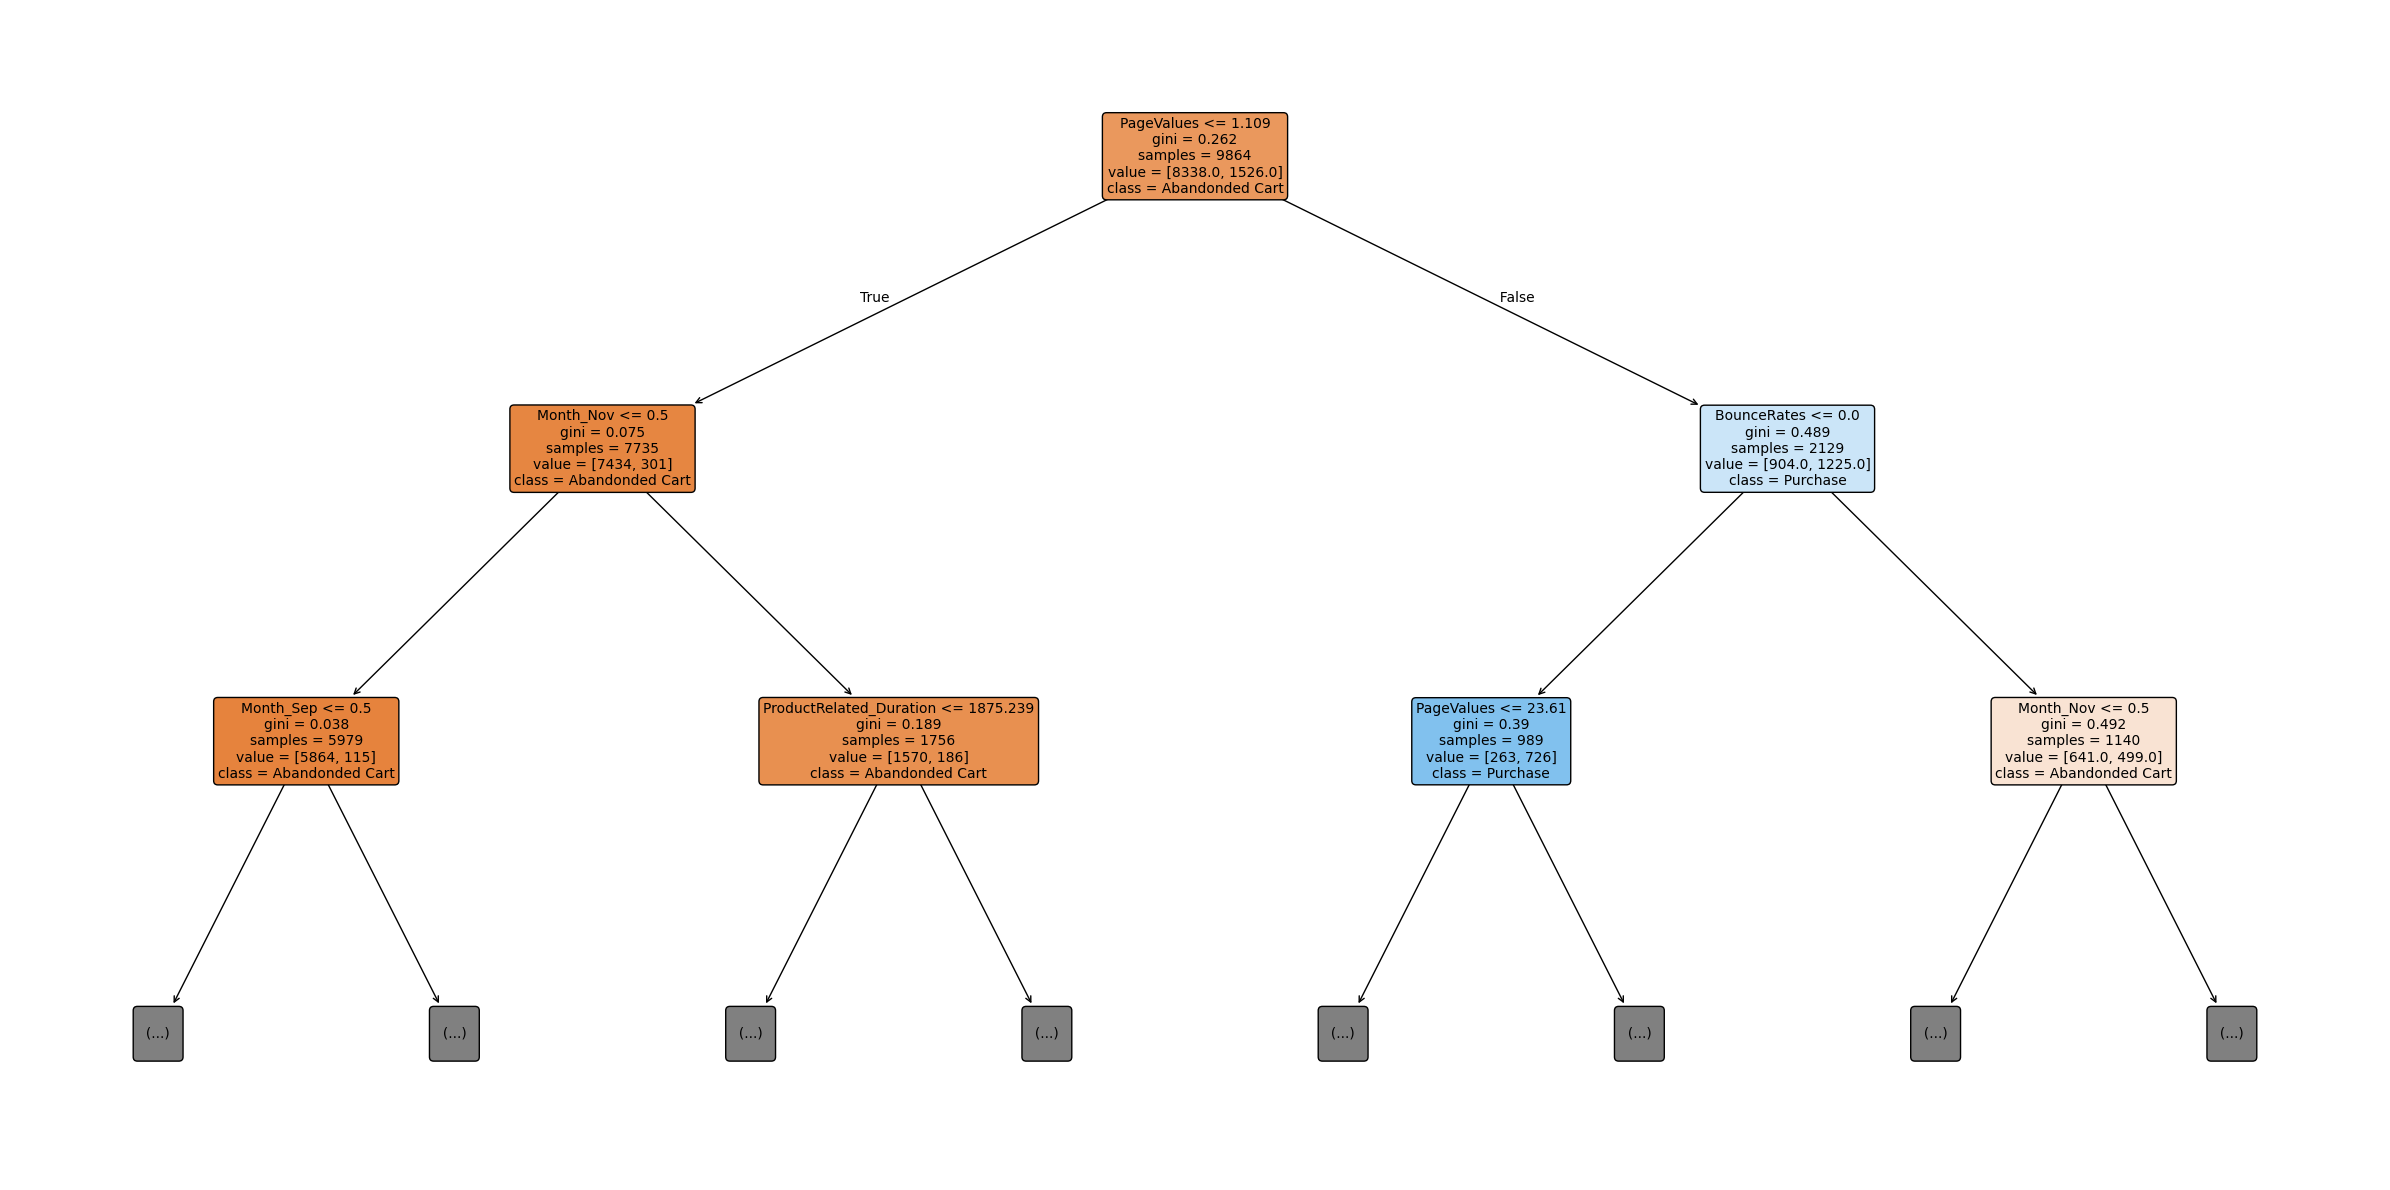

In [20]:
# Diagnosis Architecture Visualization

print("\n Exporting clean model schematic for review")

plt.figure(figsize=(24,12))
plot_tree(
    clf_tree,
    feature_names=TRAINING_FEATURE_SCHEMA,
    class_names=['Abandonded Cart', 'Purchase'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=2
)
plt.tight_layout()
plt.savefig('decision_tree_model_schematic.png', dpi=300)
plt.show()
plt.close()